In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import joblib
import warnings
warnings.filterwarnings('ignore')

In [9]:
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [10]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values
print('Shape:', X.shape)

Shape: (200, 2)


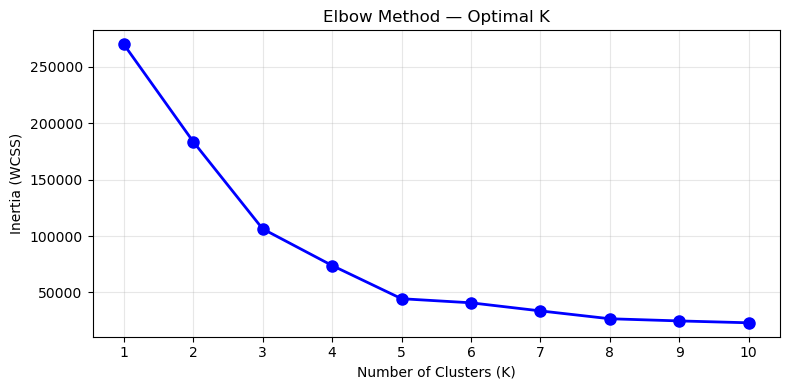

Elbow at K=5 — optimal clusters


In [11]:
# Elbow Method
inertias = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method — Optimal K')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('elbow_plot.png', dpi=150)
plt.show()
print('Elbow at K=5 — optimal clusters')

In [12]:
# Train Final Model — K=5
K = 5
kmeans = KMeans(n_clusters=K, init='k-means++', n_init=10, random_state=42)
kmeans.fit(X)

labels = kmeans.labels_
centers = kmeans.cluster_centers_

print('Cluster labels:', np.unique(labels))
print('Inertia:', round(kmeans.inertia_, 2))
print('Cluster Centers (Income, Spending):')
for i, c in enumerate(centers):
    print(f'  Cluster {i}: Income={c[0]:.1f}k, Spending={c[1]:.1f}')

Cluster labels: [0 1 2 3 4]
Inertia: 44448.46
Cluster Centers (Income, Spending):
  Cluster 0: Income=55.3k, Spending=49.5
  Cluster 1: Income=86.5k, Spending=82.1
  Cluster 2: Income=25.7k, Spending=79.4
  Cluster 3: Income=88.2k, Spending=17.1
  Cluster 4: Income=26.3k, Spending=20.9


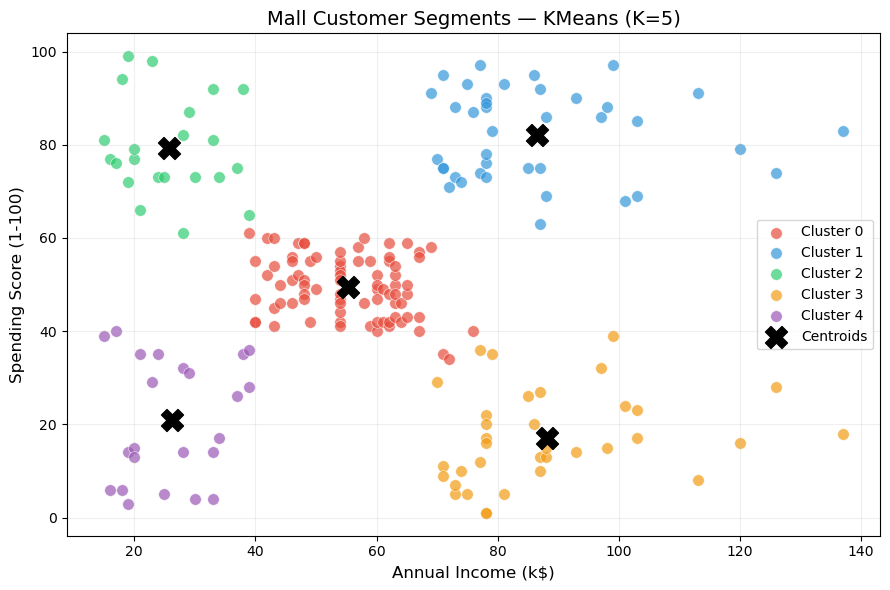

In [13]:
# Cluster Visualization
COLORS = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6']

plt.figure(figsize=(9, 6))

for i in range(K):
    mask = labels == i
    plt.scatter(X[mask, 0], X[mask, 1],
                s=70, color=COLORS[i], alpha=0.7,
                edgecolors='white', linewidths=0.5,
                label=f'Cluster {i}')

plt.scatter(centers[:, 0], centers[:, 1],
            s=250, c='black', marker='X',
            zorder=5, label='Centroids')

plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.title('Mall Customer Segments — KMeans (K=5)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('clusters_plot.png', dpi=150)
plt.show()

In [14]:
# Save model and scaler info
joblib.dump(kmeans, 'kmeans_model.pkl')

# Save cluster color map
cluster_meta = {
    'colors': COLORS,
    'k': K,
    'feature_names': ['Annual Income (k$)', 'Spending Score (1-100)']
}
joblib.dump(cluster_meta, 'cluster_meta.pkl')

# Save training data
np.save('X_train.npy', X)
np.save('labels_train.npy', labels)

print('Saved: kmeans_model.pkl, cluster_meta.pkl, X_train.npy, labels_train.npy')

Saved: kmeans_model.pkl, cluster_meta.pkl, X_train.npy, labels_train.npy
